In [42]:
# get props
# fly train
# Walk Still Frontgroom Backgroom Abdomenmove
#props = [1500, 1500, 1300, 1350, 3048]

# # fly test
#props = [1500, 1500, 1500, 1500, 1905]

# # oft train
# #Supportedrear Unsupportedrear Groom
#props = [23323, 15050, 3128]

# # oft test
#props = [24487, 13198, 3473]

# # ibl train
# #Still Move Wheel turn Groom
#props = [2274, 1437, 1820, 1803]

# # ibl test
#props = [1826, 1285, 2180, 1482]

# # huga train
# # Walking Running Goingup Goingdown Sitting Sittingdown Standingup Standing
#props = [96529, 21302, 39473, 36664, 24107, 4864, 5537, 28731]
# # huga test
props = [97465, 26378, 39965, 31345, 23097, 5651, 6395, 29281]

# all_a = [a1,a2,a3,a4,a5]
#print([sum([a[i] for a in all_a]) for i in range(len(a1))])

per = [round(p/sum(props),3) for p in props]
print(per)

[0.375, 0.102, 0.154, 0.121, 0.089, 0.022, 0.025, 0.113]


In [18]:
# # load oft f1
# ds = 'ibl'
# xs = datasets[ds]['sizes']
# f1_dict = datasets[ds]['f1s']
# #print(f1_dict)
# inputs = ['m', 'fp']#, 'fs', 'fspv']
# mod = 'tcn'

# for i in range(len(inputs)):
#     key = mod + '_' + inputs[i]
#     ys_mean = [round(f1_dict[key][str(a)]['avg']['mean'],3) for a in xs]
#     print(inputs[i], ':', ys_mean)

m : [0.826, 0.872, 0.901, 0.913]
fp : [0.909, 0.936, 0.939, 0.947]


In [11]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import os
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

In [12]:
def load_feature_csv(filepath):
    df = pd.read_csv(filepath)
    # drop first column if it just contains frame indices
    unnamed_col = 'Unnamed: 0'
    if unnamed_col in list(df.columns):
        df = df.drop([unnamed_col], axis=1)
    vals = df.values
    feature_names = list(df.columns)
    return vals, feature_names

In [13]:
datasets = {
    'fly': {
        'vids': [
            '2019_06_26_fly2',
            '2019_08_14_fly1',
            '2019_08_20_fly3',
            '2019_10_14_fly2',
            '2019_10_21_fly1',
        ],
        'parts': ['avg', 'still', 'walk', 'front_groom', 'back_groom', 'abdomen-move'],
        'sizes': [2,3,4,5],
        'ds_name': 'fly-5',
        'exts': ['m', 'fp'],
        'marker_names': [
            'abdomen-top',
            'addomen-bot',
            'hind-top',
            'hind-bot',
            'mid-top',
            'mid-bot',
            'fore-top',
            'fore-bot'
        ],
        'm_inds': [i*4 for i in range(5)],
        'props': {
            'train': [0.172, 0.172, 0.149, 0.155, 0.35],
            'test': [0.19, 0.19, 0.19, 0.19, 0.241]
        }
    },
    'oft': {
        'vids': [
            'OFT_39',
            'OFT_41',
            'OFT_43',
            'OFT_44',
            'OFT_49',
            'OFT_50',
            'OFT_51',
            'OFT_52',
            'OFT_54',
            'OFT_58',
        ],
        'parts': ['avg', 'supported', 'unsupported', 'grooming'],
        'sizes': [4,6,8,10],
        'ds_name': 'mouse-oft-aligned',
        'exts': ['m', 'fp', 'fs', 'fspv'],
        'marker_names': [
            'abdomen-top',
            'addomen-bot',
            'hind-top',
            'hind-bot',
            'mid-top',
            'mid-bot',
            'fore-top',
            'fore-bot'
        ],
        'm_inds': [i*4 for i in range(5)],
        'props': {
            'train': [0.562, 0.363, 0.075],
            'test': [0.595, 0.321, 0.084]
        }
        
    } ,
    'ibl': {
        'vids': [
            'churchlandlab_CSHL045_2020-02-27-001',
            'cortexlab_KS020_2020-02-06-001',
            'hoferlab_SWC_043_2020-09-15-001',
            'mrsicflogellab_SWC_052_2020-10-22-001',
            'wittenlab_ibl_witten_27_2021-01-21-001',
        ],
        'parts': ['avg', 'still', 'move', 'wheel_turn', 'groom'],
        'sizes': [2,3,4,5],
        'ds_name': 'ibl',
        'exts': ['m', 'fp'],
        'marker_names': [
            'paw_x',
            'paw_y',
            'wheel_vel',
        ],
        'm_inds': [0,1,2],
        'props': {
            'train': [0.31, 0.196, 0.248, 0.246],
            'test': [0.27, 0.19, 0.322, 0.219]
        }
    }, 
    'huga': {
        'vids': [
            'sess_06',
            'sess_08',
            'sess_11',
            'sess_13',
            'sess_17',
        ],
        'parts': ['avg', 'walking', 'running', 'going_up', 'going_down', 'sitting',
                     'sitting_down', 'standing_up', 'standing'],#, 'down_elevator', 'up_elevator'],
        'sizes': [100,250,500,1000],
        'ds_name': 'huga',
        'exts': ['m'],
        'marker_names': [
            'abdomen-top',
            'addomen-bot',
            'hind-top',
            'hind-bot',
            'mid-top',
            'mid-bot',
            'fore-top',
            'fore-bot'
        ],
        'm_inds': [i*6 for i in range(5)],
        'props': {
            'train': [0.375, 0.083, 0.153, 0.143, 0.094, 0.019, 0.022, 0.112],
            'test': [0.375, 0.102, 0.154, 0.121, 0.089, 0.022, 0.025, 0.113]
        }
    } 
}


ds_names = ['fly', 'oft', 'ibl', 'huga']

In [14]:
# load preds and f1s for etho
ds_names = ['fly', 'oft', 'ibl', 'huga']

# preds
pred_base = "/home/bsb2144/daart/metrics/{}/{}_{}_y_hat.npy"
gt_base = "/home/bsb2144/daart_utils/data/{}/labels-hand/{}_labels.csv"
mods = ['gt', 'tcn', 'rsl', 'rsln', 'gm', 'gmnt']
for ds in ds_names:
    temp = {}
    vid = datasets[ds]['vids'][0]
    for mod in mods:
        if mod == 'gt':
            gt_path = gt_base.format(datasets[ds]['ds_name'], vid)
            gt_pd = pd.read_csv(gt_path,index_col=0).to_numpy()
            gt = gt_pd.argmax(axis=1)
            temp['gt'] = gt
        else:
            for ext in datasets[ds]['exts']:
                if mod in ['tcn', 'rsl']:
                    key = mod + '_' + ext
                    pred_path = pred_base.format(ds, vid, key)
                    preds = np.load(pred_path)
                    temp[key] = preds
            
    datasets[ds]['preds'] = temp

# f1 scores
f1_base  = "/home/bsb2144/daart/metrics/{}/{}.json"
for ds in ds_names:
    temp = {}
    for ext in datasets[ds]['exts']:
        for mod in mods[1:]:
            key = mod + '_' + ext
            f1_path = f1_base.format(ds, key)
            with open(f1_path) as f:
                f1_scores = json.load(f)
            temp[key] = f1_scores
    datasets[ds]['f1s'] = temp
        

In [15]:
# load markers
marker_base = "/home/bsb2144/daart_utils/data/{}/{}/{}_labeled.{}"
ds_names = ['fly', 'oft', 'ibl', 'huga']
exts = ['features-posvel', 'features-sturman-posvel', 'features-posvel', 'markers']
f_type = ['csv', 'csv', 'csv', 'npy']

for i, ds in enumerate(ds_names):
    vid = datasets[ds]['vids'][0]
    
    marker_path = marker_base.format(datasets[ds]['ds_name'], exts[i], vid, f_type[i])
    if f_type[i] == 'csv':
        markers, _ = load_feature_csv(marker_path)
    else:
        markers = np.load(marker_path)
        
    # do transforms
    markers -= np.mean(markers, axis=0)
    std = np.std(markers, axis=0)
    markers[:, std > 0] = (markers[:, std > 0] / std[std > 0])
    #print('markers', markers.shape)             
    datasets[ds]['markers'] = markers

In [9]:
def graph_etho_img(fig, ds,start=0,length=600, vol=False):
    n_rows = 4
    outer_grid = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=fig)
    inner_grid = outer_grid[0].subgridspec(n_rows, 1, hspace=0, height_ratios=[.1,.1,.1,.5])
    axes = inner_grid.subplots()
    
    n_classes = len(datasets[ds]['parts'])-1
    if ds=='huga':
        tcn = datasets[ds]['preds']['tcn_m']
        s3lds = datasets[ds]['preds']['rsl_m'][:len(tcn)]
    elif vol and ds!='oft':
        tcn = datasets[ds]['preds']['tcn_fp']
        s3lds = datasets[ds]['preds']['rsl_fp'][:len(tcn)]
    elif vol and ds=='oft':
        tcn = datasets[ds]['preds']['tcn_fspv']
        s3lds = datasets[ds]['preds']['rsl_fspv'][:len(tcn)]
    elif not vol and ds=='oft':
        tcn = datasets[ds]['preds']['tcn_fs']
        s3lds = datasets[ds]['preds']['rsl_fs'][:len(tcn)]
    else:
        tcn = datasets[ds]['preds']['tcn_m']
        s3lds = datasets[ds]['preds']['rsl_m'][:len(tcn)]

    gt = datasets[ds]['preds']['gt'][:len(tcn)]
       
    # graph ground truth
    data = gt[gt>0][start:(start+length)]
    graph_states(axes[0], data, n_classes)
    axes[0].set(ylabel="GT")
    axes[0].yaxis.label.set(rotation='horizontal', ha='right')
    
    # graph tcn predictions
    data = tcn[gt>0][start:(start+length)]
    graph_states(axes[1], data, n_classes)
    axes[1].set(ylabel="TCN")
    axes[1].yaxis.label.set(rotation='horizontal', ha='right')
    
    # graph s3lds predcitions
    data = s3lds[gt>0][start:(start+length)]
    #print('markers',markers.shape)
    #print('data s3', data.shape)
    graph_states(axes[2], data, n_classes)
    axes[2].set(ylabel=f'S\N{SUPERSCRIPT THREE}LDS')
    axes[2].yaxis.label.set(rotation='horizontal', ha='right')
    
    # graph markers
    markers = datasets[ds]['markers'][:len(gt)][gt>0][start:(start+length)]
    print('markers',markers.shape)
    marker_names = datasets[ds]['marker_names']
    m_inds = datasets[ds]['m_inds']
    graph_markers(axes[3], markers, marker_names, m_inds, ds)
    
    
def graph_states(ax, states, n_classes):
    n_frames = states.shape[0]
    im = ax.imshow(
        states[None, :], aspect='auto', 
        cmap=cmap, interpolation='none',
        vmin=1, vmax=n_classes)
    ax.set_xticks([])
    ax.set_yticks([])
    
def graph_markers(ax, markers, marker_names, m_inds, ds):
    # plot markers
    spc =  1.0 * abs(markers.max())
    for n in range(len(m_inds)):
        m_tmp = markers[:, m_inds[n]]
        #print('m_tmp',m_tmp.shape)
        ax.plot(np.array(range(len(m_tmp))) , m_tmp + spc*n, color='k', linewidth=2)
        
    ax.set_xlim([0, len(m_tmp) - 1])
    ax.set_xticks([0,200,400,600,800,1000])
    ax.spines[['right','left']].set_visible(False)
    ax.set_yticks(spc * np.arange(len(m_inds)))
    if ds != 'oft':
        marker_labels = [marker_names[m] for m in range(len(m_inds))] 
    else:
        marker_labels = [marker_names[m] for m in range(len(m_inds))]
    ax.set_yticklabels(marker_labels)
    
def graph_f1(ax, ds, mods=['tcn', 'rsl']):
    xs = datasets[ds]['sizes']
    f1_dict = datasets[ds]['f1s']
    #print(f1_dict)
    inputs = ['m', 'fp']
    if ds == 'oft':
        inputs=['fs', 'fspv']
    elif ds == 'huga':
        inputs=['m']
        
    for mod in mods: 
        for i in range(len(inputs)):
            key = mod + '_' + inputs[i]
            ys_mean = [f1_dict[key][str(a)]['avg']['mean'] for a in xs]
            ys_sd = [f1_dict[key][str(a)]['avg']['sd'] for a in xs]
            ls = '--'
            if i==0:
                ls = '-'
            ax.errorbar(xs, ys_mean, label=mod, linestyle=ls, color=color_dict[mod], yerr=ys_sd)
    ax.spines[['right','top']].set_visible(False)
    ax.legend()

def graph_bars(ax, ds, train=True, legend=True):
    
    x = datasets[ds]['parts'][1:]
    
    if train:
        y = datasets[ds]['props']['train']

        width = 0.75 # the width of the bars 
        ind = np.arange(len(y))  # the x locations for the groups

        ax.barh(ind, y, width, color=colors, align='edge')
        ax.set_yticks([])

        for bar, disease in zip(ax.patches, x):
            ax.text(0.01, bar.get_y()+bar.get_height()/2, disease, ha = 'left', va = 'center') 
            
    else:
        y1 = datasets[ds]['props']['train']
        y2 = datasets[ds]['props']['test']
        
        width = 0.4 # the width of the bars 
        ind = np.arange(len(y1))  # the x locations for the groups
        
        colors2 = plt.cm.tab20.colors[1:][::2][:len(datasets[ds_names[r]]['parts'])-1]
        ax.barh(ind, y1, width, color=colors, align='edge', label='train')
        ax.barh(ind + width, y2, width, color=colors2, align='edge', label='test')

        #ax.set(yticks=ind + width, yticklabels=df.graph, ylim=[2*width - 1, len(df)])
        if legend:
            ax.legend()
        ax.set_yticks([])

        for bar, disease in zip(ax.patches, x):
            ax.text(0.01, bar.get_y()+bar.get_height()/1.5, disease, ha = 'left', va = 'center') 

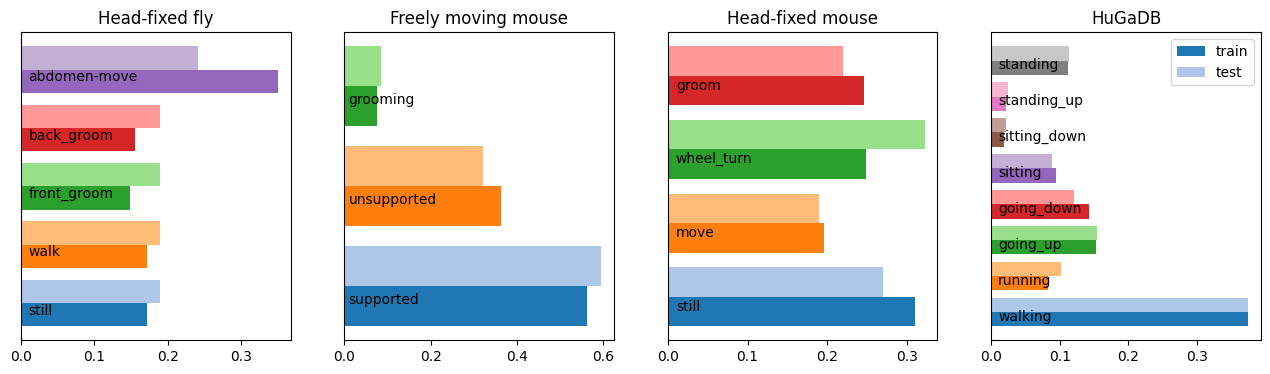

In [10]:
ds_names = ['fly', 'oft', 'ibl', 'huga']
titles = ['Head-fixed fly', 'Freely moving mouse', 'Head-fixed mouse', 'HuGaDB']
start=0
length=1000
n_cols = 4
n_rows = 1

fig_width = 16
fig_height = 4

fig = plt.figure(figsize=(fig_width, fig_height))
outer_grid = fig.add_gridspec(n_rows, 1, hspace=0.1)
inner_grid = [outer_grid[r].subgridspec(1, n_cols, hspace=0) for r in range(n_rows)]
axes = inner_grid[0].subplots()
for r in range(n_cols):   
    
    colors = plt.cm.tab10.colors[:len(datasets[ds_names[r]]['parts'])-1]
    cmap = ListedColormap(colors)
    # graph train/test percents
    graph_bars(axes[r], ds_names[r], False, r==(n_cols-1))
    axes[r].set_title(titles[r])

In [84]:
color_dict = {
    'tcn': 'grey',
    'rsl': 'black',
    'rsln': 'tab:blue',
    'gm':'tab:green',
    'gmnt': 'tab:red'
}

markers (1000, 32)
markers (1000, 42)
markers (1000, 6)
markers (1000, 36)


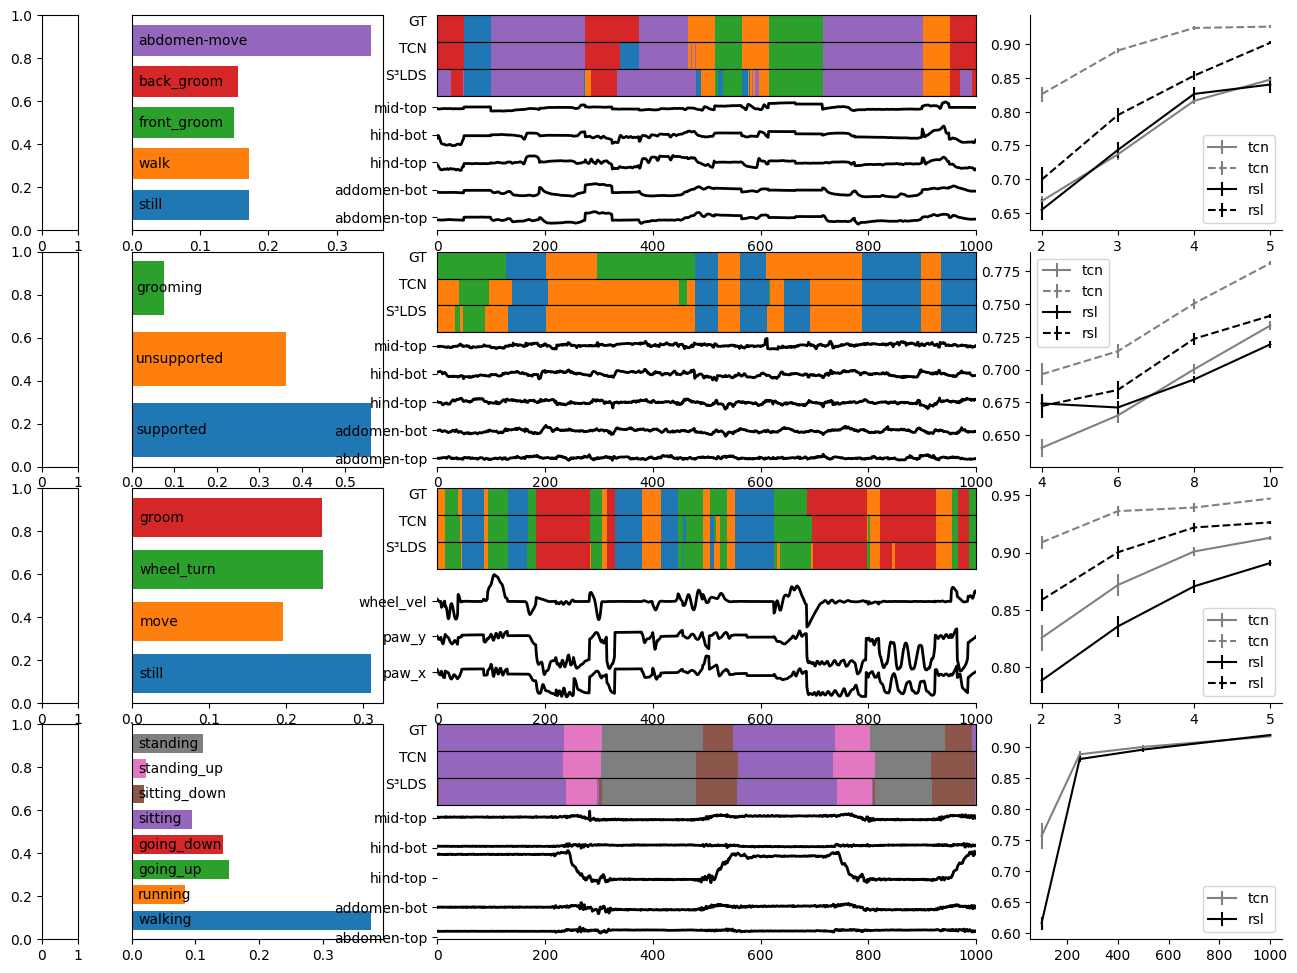

In [85]:
ds_names = ['fly', 'oft', 'ibl', 'huga']
start=0
length=1000
n_cols = 4
n_rows = 4

fig_width = 16
fig_height = 12

fig = plt.figure(figsize=(fig_width, fig_height))
outer_grid = fig.add_gridspec(n_rows, 1, hspace=0.1)
inner_grid = [outer_grid[r].subgridspec(1, n_cols, hspace=0, width_ratios=[.1,.7,1.5,.7]) for r in range(n_rows)]

for r in range(n_rows):   
    axes = inner_grid[r].subplots()
    colors = plt.cm.tab10.colors[:len(datasets[ds_names[r]]['parts'])-1]
    cmap = ListedColormap(colors)
    # graph train percents
    graph_bars(axes[1], ds_names[r])
    
    # graph etho
    graph_etho_img(axes[2], ds_names[r],start=start,length=length, vol=True)
    axes[2].axis('off')
    
    # graph f1
    graph_f1(axes[3], ds_names[r],mods=['tcn', 'rsl'])
    
    
# if n_rows == 1:
#     fig.subplots_adjust(bottom=0.2, top=0.8)
# else:
#     fig.subplots_adjust(bottom=0.08, top=0.94)
# fig.suptitle('%s bouts (%s)' % (label_name.capitalize(), expt_id_test))


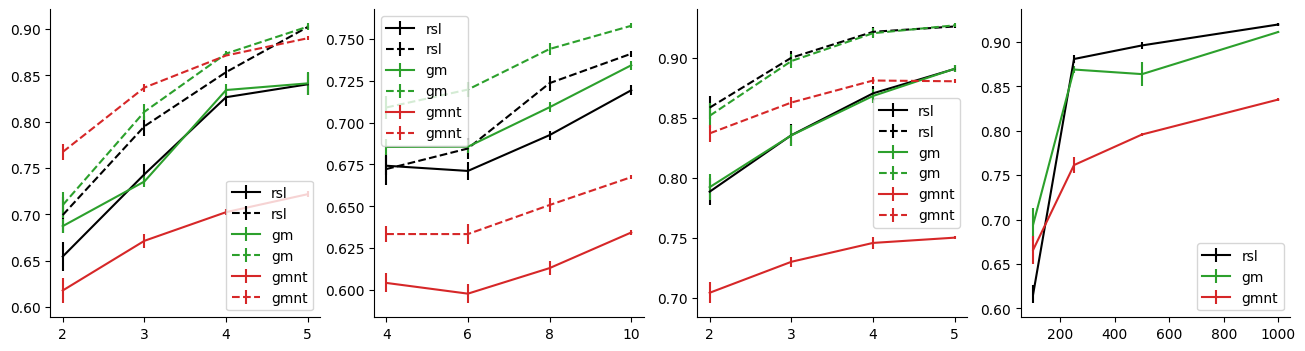

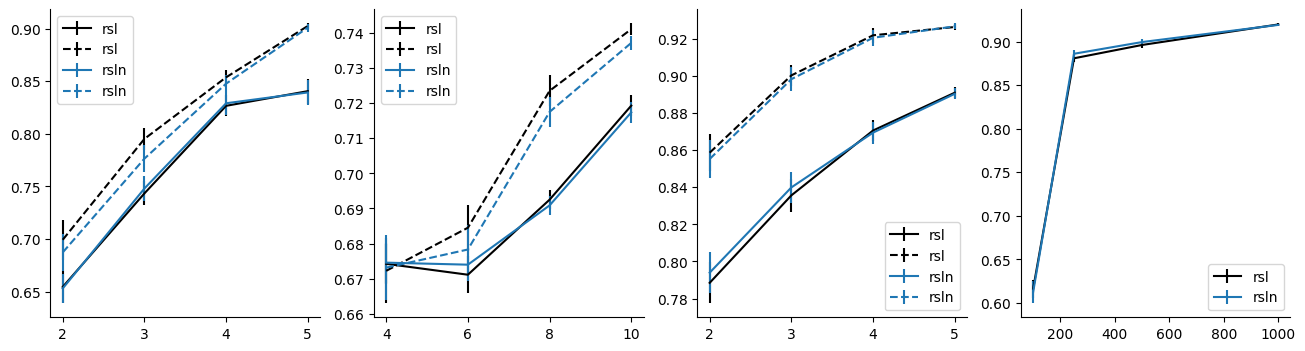

In [70]:
ds_names = ['fly', 'oft', 'ibl', 'huga']
start=0
length=1000
n_cols = 4
n_rows = 1

fig_width = 16
fig_height = 4

fig = plt.figure(figsize=(fig_width, fig_height))
outer_grid = fig.add_gridspec(n_rows, 1, hspace=0.1)
inner_grid = [outer_grid[r].subgridspec(1, n_cols, hspace=0) for r in range(n_rows)]
axes = inner_grid[0].subplots()
for r in range(n_cols):   
    
    colors = plt.cm.tab10.colors[:len(datasets[ds_names[r]]['parts'])-1]
    cmap = ListedColormap(colors)
    # graph train percents
    
    #graph_f1(axes[r], ds_names[r], mods=['tcn', 'rsl', 'rsln'])
    graph_f1(axes[r], ds_names[r], mods=[ 'rsl', 'gm', 'gmnt'])
    
    
# if n_rows == 1:
#     fig.subplots_adjust(bottom=0.2, top=0.8)
# else:
#     fig.subplots_adjust(bottom=0.08, top=0.94)
# fig.suptitle('%s bouts (%s)' % (label_name.capitalize(), expt_id_test))
#ds_names = ['fly', 'oft', 'ibl', 'huga']


fig = plt.figure(figsize=(fig_width, fig_height))
outer_grid = fig.add_gridspec(n_rows, 1, hspace=0.1)
inner_grid = [outer_grid[r].subgridspec(1, n_cols, hspace=0) for r in range(n_rows)]
axes = inner_grid[0].subplots()
for r in range(n_cols):   
    
    colors = plt.cm.tab10.colors[:len(datasets[ds_names[r]]['parts'])-1]
    cmap = ListedColormap(colors)
    # graph train percents
    
    graph_f1(axes[r], ds_names[r], mods=['rsl', 'rsln'])
    #graph_f1(axes[r], ds_names[r], mods=['tcn', 'rsl', 'gm', 'gmnt'])
    
    
# if n_rows == 1:
#     fig.subplots_adjust(bottom=0.2, top=0.8)
# else:
#     fig.subplots_adjust(bottom=0.08, top=0.94)
# fig.suptitle('%s bouts (%s)' % (label_name.capitalize(), expt_id_test))

